## Model Training 

1. Data Preprocessing & Feature Engineering

Encoding: Applying Target Encoding or One-Hot Encoding for categorical variables.

Feature Scaling: Normalizing or Standardizing features (crucial for distance-based models like SVM or Neural Nets).

Feature Creation: Interaction terms, polynomial features, or time-series lags based on EDA findings.

2. Dataset Splitting Strategy

Didn't just do a random 80/20 split. Strategy employed matches the data's nature:

Time-Series: Use a Sliding Window or Expanding Window split to avoid "look-ahead" bias.

Imbalanced Data: Use Stratified Splits to ensure the minority class is represented in both sets.

Small Datasets: Implement k-fold Cross-Validation to ensure stability.

3. Baseline Model Selection

Before jumping to Deep Learning, establish a "vanilla" baseline (e.g., Logistic Regression or a simple Random Forest).

Why? If a complex Transformer only beats a simple Linear Regression by 1%, the added latency and cost probably aren't worth it.

4. Model Training & Hyperparameter Optimization

This is an iterative loop. We use systematic search patterns rather than "gut feelings."

Search Strategies: * Bayesian Optimization: More efficient than Grid Search; it learns which hyperparameter combinations are likely to succeed.

Random Search: Surprisingly effective for high-dimensional spaces.

Regularization: Applying L1 (Lasso) or L2 (Ridge) penalties to prevent the model from memorizing noise (overfitting).

5. Model Evaluation (Beyond Accuracy)
Accuracy is a trap. I look at the metrics that actually matter for the business case:

Precision/Recall & F1-Score: Especially for imbalanced classification.

ROC-AUC / PR-AUC: To understand the trade-off between True Positives and False Positives.

Error Analysis: Inspecting the "Hard Samples"—the ones the model got wrong—to see if there’s a pattern we missed in EDA.

6. Model Interpretation & Versioning
In a professional setting, "black box" models don't fly.

Explainability: Use SHAP or LIME to explain why a model made a specific prediction.

Experiment Tracking: Tools like MLflow or Weights & Biases are essential. You need to log every version of your code, data, and hyperparameters so you can reproduce results.

The ML Pipeline Checklist
Stage	Goal	Key Tooling
Data Ops	Scalable cleaning	Spark, Dask, SQL
Training	Optimization	Scikit-learn, XGBoost, PyTorch
Tracking	Reproducibility	MLflow, DVC
Validation	Generalization	Cross-validation, SHAP
Automating the pipeline

Handling data drift

Real-time inference needs

Cloud deployment options



# Model Training

- import dependencies data 
- Data Preprocessing & Feature Engineering 
- Dataset Split

## 1 Import Data and Dependencies

### 1. 1 Import data and required packages

- importing Pandas, Numpy, Matplotlib, Seaborn and library and require models

In [143]:
# Basic Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

Import the CSV Data as pandas dataframe

In [144]:
filename = r'./data/stud.csv'
df = pd.read_csv(filename)

Show top 5 records

In [145]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


###  1.2 optimize 


In [146]:
# memory optimization
import utils
import importlib
importlib.reload(utils)
from utils import Variables
vars = Variables(df)
vars.refresh()

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   category
 1   race_ethnicity               1000 non-null   category
 2   parental_level_of_education  1000 non-null   category
 3   lunch                        1000 non-null   category
 4   test_preparation_course      1000 non-null   category
 5   math_score                   1000 non-null   int8    
 6   reading_score                1000 non-null   int8    
 7   writing_score                1000 non-null   int8    
dtypes: category(5), int8(3)
memory usage: 8.7 KB


## 2 Data Preprocessing and Feature engineering

- add the average column to the dataset
- We predict average using demographic and preparation features only. We exclude other scores - math, reading and writing scores - from features to ensure the model predicts independently and avoid data leakage.
- creation new features from categorical data using interaction terms

In [148]:
def new_cat_feature(columns:list):
    """ Create new categorical features from columns. With a maximum combination of three columns"""

    if not columns:
        raise ValueError("Your column list is empty")

    for column in columns:
        if column not in vars.categorical_var and column not in vars.object_var:
            raise NameError("Columnn you want to combine does not exist in the dataframe or is not a categorical variables.")
    
    if len(columns) == 2:
        new_feature_name = columns[0] + "_" + columns[1]
        df[new_feature_name] = df[columns[0]].astype(str) + "_" + df[columns[1]].astype(str)
    elif len(columns) == 3:
        new_feature_name = columns[0] + "_" + columns[1] + "_" + columns[2]
        df[new_feature_name] = df[columns[0]].astype(str) + "_" + df[columns[1]].astype(str) + "_" + df[columns[2]].astype(str)
    else:
        raise ValueError("Number of columns to combine must not be greater than 3 or less than 2")
    
    return new_feature_name
    
    



- Exploratory data analysis shows that there is an intersection between parental level of education and gender
- Moreover, studies have also shown that this intersection exists

"Parental education significantly predicted parental expectation, parent-child activity and reading achievement... the process of how family SES relates to "
"reading achievement was not the same for [boys and girls]." — Frontiers in Psychology, "Gender Differences in How Family Income and Parental Education..."
[https://pmc.ncbi.nlm.nih.gov/articles/PMC5992380/].

- lunch and test preparation course also show somewhat interconnection



In [168]:
# feature1 = ['gender', 'race_ethnicity']
feature4 = ['gender', 'parental_level_of_education']

# feature7 = ['race_ethnicity', 'test_preparation_course']

feature8 = ['lunch', 'test_preparation_course']

features = [feature4, feature8]

# Average column
df['average'] = df[vars.numerical_var].sum(axis=1) / len(vars.numerical_var)

for feature in features:
    try: 
        new_feature = new_cat_feature(feature)
        print(f"{new_feature.title()} has successfully been added!")
    except Exception as e:
        print("An error occured", e)

Gender_Parental_Level_Of_Education has successfully been added!
Lunch_Test_Preparation_Course has successfully been added!


In [169]:
# Optimize memory
vars.refresh()

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   gender                              1000 non-null   category
 1   race_ethnicity                      1000 non-null   category
 2   parental_level_of_education         1000 non-null   category
 3   lunch                               1000 non-null   category
 4   test_preparation_course             1000 non-null   category
 5   math_score                          1000 non-null   int8    
 6   reading_score                       1000 non-null   int8    
 7   writing_score                       1000 non-null   int8    
 8   average                             1000 non-null   float32 
 9   gender_parental_level_of_education  1000 non-null   object  
 10  lunch_test_preparation_course       1000 non-null   category
dtypes: category(6), float32(1), int

In [171]:
numeric = [var for var in vars.numerical_var]

untransformed_X = df.drop(columns=['math_score', 'average'])
untransformed_X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score,gender_parental_level_of_education,lunch_test_preparation_course
0,female,group B,bachelor's degree,standard,none,72,74,female_bachelor's degree,standard_none
1,female,group C,some college,standard,completed,90,88,female_some college,standard_completed
2,female,group B,master's degree,standard,none,95,93,female_master's degree,standard_none
3,male,group A,associate's degree,free/reduced,none,57,44,male_associate's degree,free/reduced_none
4,male,group C,some college,standard,none,78,75,male_some college,standard_none


In [172]:
untransformed_X.shape

(1000, 9)

In [173]:
print(vars.categorical_var)
untransformed_X.info()

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   gender                              1000 non-null   category
 1   race_ethnicity                      1000 non-null   category
 2   parental_level_of_education         1000 non-null   category
 3   lunch                               1000 non-null   category
 4   test_preparation_course             1000 non-null   category
 5   reading_score                       1000 non-null   int8    
 6   writing_score                       1000 non-null   int8    
 7   gender_parental_level_of_education  1000 non-null   object  
 8   lunch_test_preparation_course       1000 non-null   category
dtypes: category(6), int8(2), object(1)
memory usage: 16.7+ KB


In [174]:
y = df['math_score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int8

In [175]:
# Create Column Transformer with 3 types of transformers
X_vars = Variables(untransformed_X)
X_vars.refresh()
cat_features = X_vars.categorical_var
num_features = X_vars.numerical_var
obj_features = X_vars.object_var

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

cat_transformer = OneHotEncoder()
num_transformer = StandardScaler()

cat_features = cat_features + obj_features

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", cat_transformer, cat_features),
        ("StandardEncoder", num_transformer, num_features), 
    ]
)

In [176]:
X = preprocessor.fit_transform(untransformed_X)

In [177]:
print(X[:])

  (0, 0)	1.0
  (0, 3)	1.0
  (0, 8)	1.0
  (0, 14)	1.0
  (0, 16)	1.0
  (0, 20)	1.0
  (0, 22)	1.0
  (0, 33)	0.19399858403803502
  (0, 34)	0.3914918076496706
  (1, 0)	1.0
  (1, 4)	1.0
  (1, 11)	1.0
  (1, 14)	1.0
  (1, 15)	1.0
  (1, 19)	1.0
  (1, 25)	1.0
  (1, 33)	1.4274759816659497
  (1, 34)	1.3132686840532009
  (2, 0)	1.0
  (2, 3)	1.0
  (2, 10)	1.0
  (2, 14)	1.0
  (2, 16)	1.0
  (2, 20)	1.0
  (2, 24)	1.0
  :	:
  (997, 9)	1.0
  (997, 13)	1.0
  (997, 15)	1.0
  (997, 17)	1.0
  (997, 23)	1.0
  (997, 33)	0.1254720619475953
  (997, 34)	-0.2010790414668845
  (998, 0)	1.0
  (998, 5)	1.0
  (998, 11)	1.0
  (998, 14)	1.0
  (998, 15)	1.0
  (998, 19)	1.0
  (998, 25)	1.0
  (998, 33)	0.6051577165806732
  (998, 34)	0.5890154240218557
  (999, 0)	1.0
  (999, 5)	1.0
  (999, 11)	1.0
  (999, 13)	1.0
  (999, 16)	1.0
  (999, 18)	1.0
  (999, 25)	1.0
  (999, 33)	1.153369893304191
  (999, 34)	1.1815862731384108


In [178]:
print(y)

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int8


### Training data
How Training data looks like

In [179]:
X_dense = X.toarray()

# Get OneHotEncoder columns
ohe_columns = preprocessor.named_transformers_['OneHotEncoder'].get_feature_names_out(cat_features)
columns_name = []
columns_name.extend(ohe_columns)
columns_name.extend(num_features)
print(columns_name)
print(len(columns_name))
excel_file = r'./training_data.xlsx'
save_df = pd.DataFrame(X_dense, columns=columns_name)
save_df['target'] = y
save_df.to_excel(excel_file, index=False)
print(f"Saved Training data to {excel_file}")

['gender_female', 'gender_male', 'race_ethnicity_group A', 'race_ethnicity_group B', 'race_ethnicity_group C', 'race_ethnicity_group D', 'race_ethnicity_group E', "parental_level_of_education_associate's degree", "parental_level_of_education_bachelor's degree", 'parental_level_of_education_high school', "parental_level_of_education_master's degree", 'parental_level_of_education_some college', 'parental_level_of_education_some high school', 'lunch_free/reduced', 'lunch_standard', 'test_preparation_course_completed', 'test_preparation_course_none', 'lunch_test_preparation_course_free/reduced_completed', 'lunch_test_preparation_course_free/reduced_none', 'lunch_test_preparation_course_standard_completed', 'lunch_test_preparation_course_standard_none', "gender_parental_level_of_education_female_associate's degree", "gender_parental_level_of_education_female_bachelor's degree", 'gender_parental_level_of_education_female_high school', "gender_parental_level_of_education_female_master's degre

Saved Training data to ./training_data.xlsx


## 3 Dataset Split

In [180]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 35), (200, 35))

Create an Evaluate Function to give all metrics after model training

In [181]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)

    return mae, rmse, r2_square

In [182]:

models = {
    "Linear Regression": LinearRegression(), 
    "Lasso": Lasso(),
    "Ridge": Ridge(), 
    "KN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []

error_results = {}
train_mae_list = []
test_mae_list = []
train_rmse_list = []
test_rmse_list = []
train_r2_list = []
test_r2_list = []
y_train_acc = []
y_test_acc = []

for model_name, model in models.items():
    
    print(f"Training {model_name}")
    print("-" * 40)

    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_predict = model.predict(X_train)
    y_test_predict = model.predict(X_test)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_predict)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_predict)

    model_list.append(model_name)
    train_mae_list.append(model_train_mae)
    test_mae_list.append(model_test_mae)
    train_rmse_list.append(model_train_rmse)
    test_rmse_list.append(model_test_rmse)
    train_r2_list.append(model_train_r2)
    test_r2_list.append(model_test_r2)
    
    print("-" * 40)

error_results["model"] = model_list
error_results["train_mae"] = train_mae_list
error_results["test_mae"] = test_mae_list
error_results["train_rmse"] = train_rmse_list
error_results["test_rmse"] = test_rmse_list
error_results["train_r2"] = train_r2_list
error_results["test_r2"] = test_r2_list

print("=" * 40) 
print("Done Training all models.")

Training Linear Regression
----------------------------------------
----------------------------------------
Training Lasso
----------------------------------------
----------------------------------------
Training Ridge
----------------------------------------
----------------------------------------
Training KN Regressor
----------------------------------------
----------------------------------------
Training Decision Tree Regressor
----------------------------------------
----------------------------------------
Training Random Forest Regressor
----------------------------------------
----------------------------------------
Training XGB Regressor
----------------------------------------
----------------------------------------
Training CatBoosting Regressor
----------------------------------------
----------------------------------------
Training AdaBoost Regressor
----------------------------------------
----------------------------------------
Done Training all models.


In [183]:
results_df = pd.DataFrame(error_results)

In [184]:
results_df

,model,train_mae,test_mae,train_rmse,test_rmse,train_r2,test_r2
0,Linear Regression,4.261062,4.227151,5.318067,5.390586,0.874552,0.880584
1,Lasso,5.206303,5.157881,6.593816,6.519694,0.807146,0.825320
2,Ridge,4.259224,4.223563,5.318326,5.387857,0.874540,0.880705
3,KN Regressor,4.952250,6.189000,6.208345,7.890387,0.829035,0.744150
4,Decision Tree Regressor,0.018750,6.525000,0.279508,8.253787,0.999653,0.720040
5,Random Forest Regressor,1.857285,4.640871,2.321917,6.000347,0.976086,0.852041
6,XGB Regressor,0.609155,4.922286,0.893413,6.313508,0.996460,0.836194
7,CatBoosting Regressor,2.348893,4.715550,2.967779,6.104904,0.960932,0.846839
8,AdaBoost Regressor,4.756982,4.735658,5.786372,6.255996,0.851486,0.839164


In [185]:
pd.DataFrame({"Model Name":model_list, "Test R2_Score":test_r2_list}).sort_values(by=["Test R2_Score"], ascending=False)

,Model Name,Test R2_Score
2,Ridge,0.880705
0,Linear Regression,0.880584
5,Random Forest Regressor,0.852041
7,CatBoosting Regressor,0.846839
8,AdaBoost Regressor,0.839164
6,XGB Regressor,0.836194
1,Lasso,0.825320
3,KN Regressor,0.744150
4,Decision Tree Regressor,0.720040


### Linear Regression 

In [186]:
lin_model = LinearRegression(n_jobs=-1)
lin_model.fit(X_train, y_train)
y_test_pred = lin_model.predict(X_test)
y_train_pred = lin_model.predict(X_train)
test_score = r2_score(y_test, y_test_pred) * 100

# Implementing oob dataset
# lin_model = RandomForestRegressor(oob_score=True, n_estimators=150, max_depth=4, random_state=42, n_jobs=-1, min_samples_split=50)
# lin_model.fit(X, y)
# y_pred = lin_model.predict(X)
# test_score = lin_model.oob_score_ * 100

train_score = r2_score(y_train, y_train_pred) * 100
print(f"Accuracy of the model on test is {test_score:.2f}")
print(f"Accuracy of the model on train is {train_score:.2f}")

Accuracy of the model on test is 88.06
Accuracy of the model on train is 87.46


Text(0.5, 1.0, 'Training Scores')

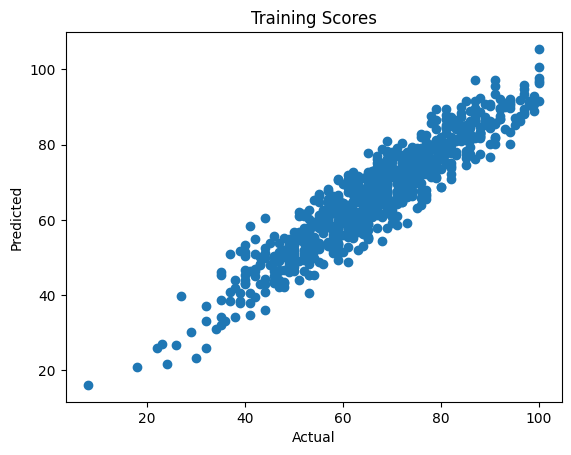

In [190]:
plt.scatter(y_train, y_train_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Training Scores")

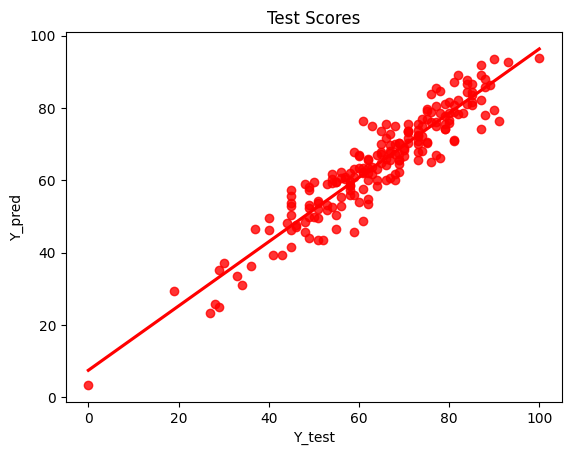

In [191]:
sns.regplot(x=y_test, y=y_test_pred, ci=None, color='red')
plt.xlabel("Y_test")
plt.ylabel("Y_pred")
plt.title('Test Scores')
plt.show()

In [192]:
lin_df = pd.DataFrame({"Actual Value":y_test, "Predicted Value":y_test_pred, "Difference":y_test-y_test_pred})

In [193]:
lin_df

,Actual Value,Predicted Value,Difference
521,91,76.472356,14.527644
737,53,58.930237,-5.930237
740,80,76.609632,3.390368
660,74,76.849385,-2.849385
411,84,87.591923,-3.591923
...,...,...,...
408,52,43.488792,8.511208
332,62,62.014987,-0.014987
208,74,67.942720,6.057280
613,65,67.113086,-2.113086


In [194]:
lin_df['Difference'].max()

14.52764431242889

In [195]:
lin_df['Difference'].min()

-15.398253206675733